# Validation 08: Joint DSPS + Cue spectro-photometric fit

This notebook validates the real joint likelihood path. It uses the same DSPS + Cue model to generate:

- a PRISM-like spectrum;
- broad-band photometry;
- one upper-limit band.

The fit consumes the same data vector a real analysis would: active spectral pixels plus active photometric bands. No analytic stellar approximation or toy nebular line model is used.

In [1]:
OUTPUT_NAME = 'validation_08_dsps_cue_joint_spectrophotometry'
DEFAULT_WARMUP = '60'
DEFAULT_SAMPLES = '80'

from pathlib import Path
import os
import time
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='Trying to unpickle estimator.*')

# Keep the notebook runnable from either the repository root or notebooks/validation.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'sedinfer').exists():
    REPO_ROOT = Path.cwd().parents[1]

OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / OUTPUT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Real pipeline resources. The SSP file must be continuum-only; Cue adds nebular emission.
SSP_FILE = Path(os.environ.get(
    'DSPS_CONTINUUM_SSP_FILE',
    REPO_ROOT / 'outputs' / 'experimental_dsps_fsps_clock_diagnostic' / 'fsps_continuum_ssp_data.h5',
))
CUE_DATA_DIR = Path(os.environ.get('CUE_DATA_DIR', '/private/tmp/cue/src/cue/data'))

RUN_NUTS = os.environ.get('SEDINFER_VALIDATE_RUN_NUTS', '1') == '1'
NUM_WARMUP = int(os.environ.get('SEDINFER_VALIDATE_NUM_WARMUP', DEFAULT_WARMUP))
NUM_SAMPLES = int(os.environ.get('SEDINFER_VALIDATE_NUM_SAMPLES', DEFAULT_SAMPLES))
RNG_SEED = int(os.environ.get('SEDINFER_VALIDATE_SEED', '8128'))

print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('SSP file:', SSP_FILE)
print('Cue data dir:', CUE_DATA_DIR)
INIT_NUM_CANDIDATES = int(os.environ.get('SEDINFER_VALIDATE_INIT_NUM_CANDIDATES', '512'))
INIT_NUM_STARTS = int(os.environ.get('SEDINFER_VALIDATE_INIT_NUM_STARTS', '8'))
INIT_OPTIMIZER_STEPS = int(os.environ.get('SEDINFER_VALIDATE_INIT_OPTIMIZER_STEPS', '120'))
INIT_LEARNING_RATE = float(os.environ.get('SEDINFER_VALIDATE_INIT_LEARNING_RATE', '0.03'))

print('Run NUTS:', RUN_NUTS, 'warmup:', NUM_WARMUP, 'samples:', NUM_SAMPLES)
print(
    'QMC+Nadam init:',
    'candidates=', INIT_NUM_CANDIDATES,
    'starts=', INIT_NUM_STARTS,
    'steps=', INIT_OPTIMIZER_STEPS,
    'learning_rate=', INIT_LEARNING_RATE,
)

missing = []
if not SSP_FILE.exists():
    missing.append(f'Missing continuum-only DSPS SSP file: {SSP_FILE}')
if not CUE_DATA_DIR.exists():
    missing.append(f'Missing Cue data directory: {CUE_DATA_DIR}')
if missing:
    raise FileNotFoundError('\n'.join(missing))


Repository: /Users/gregoire/Documents/Sedfitting/sedinfer-public
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/validation_08_dsps_cue_joint_spectrophotometry
SSP file: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/experimental_dsps_fsps_clock_diagnostic/fsps_continuum_ssp_data.h5
Cue data dir: /private/tmp/cue/src/cue/data
Run NUTS: True warmup: 50 samples: 500
QMC+Nadam init: candidates= 512 starts= 8 steps= 120 learning_rate= 0.03


In [2]:

from dsps import load_ssp_templates

from sedinfer.experimental.jaxcigale import (
    CueJaxPort,
    GaussianPhotometricData,
    GaussianSpectralData,
    GaussianSpectroPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    build_jax_sed_model,
    cue_nebular_module,
    delayed_sfh_cosmic_time_module,
    dsps_stellar_module,
    madau_igm_module,
    modified_starburst_attenuation_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    require_continuum_ssp_path,
    run_numpyro_nuts,
)
from sedinfer.experimental.jaxcigale.core import flat_lcdm_age_gyr_numpy
from sedinfer.experimental.jaxcigale.dependencies import require_jax
from sedinfer.experimental.jaxcigale.spectroscopy import model_spectrum_on_observed_pixels

jax, jnp = require_jax()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())
print('JAX scalar dtype:', np.asarray(jnp.asarray(1.0)).dtype)

ssp_data = load_ssp_templates(fn=str(require_continuum_ssp_path(SSP_FILE)))
cue_port = CueJaxPort.from_public_cue_data_dir(CUE_DATA_DIR)
cue_apply = cue_port.make_nebular_apply(line_sigma_a=1.5)
print('Loaded continuum-only SSP and Cue emulator data.')


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX scalar dtype: float64


Loaded continuum-only SSP and Cue emulator data.


In [3]:

def gaussian_filter_set(filter_specs, n_wave=192):
    """Create simple transparent filters for validation.

    Wavelengths are observed-frame Angstrom. These are not official survey
    curves; they are smooth broadbands used only to exercise the integration.
    """
    names, waves, trans = [], [], []
    for name, center_a, sigma_a in filter_specs:
        w = np.linspace(center_a - 4.0 * sigma_a, center_a + 4.0 * sigma_a, n_wave)
        t = np.exp(-0.5 * ((w - center_a) / sigma_a) ** 2)
        names.append(name)
        waves.append(w)
        trans.append(t)
    return JaxFilterSet.from_curves(names, waves, trans)


def make_dsps_cue_model(rest_wave_a, filters, parameter_space, n_sfh_time=96):
    """Build the real validation model: SFH -> DSPS -> Cue -> dust -> IGM -> redshift."""
    fixed_parameters = {
        'E_BV_old_factor': 0.5,
        'powerlaw_slope': 0.0,
        'uv_bump_amplitude': 0.0,
        'E_BV_nebular': 0.12,
        'gas_logn_h': 2.0,
        'gas_logno': -0.134,
        'gas_logco': -0.134,
        'gas_f_esc': 0.0,
        'gas_f_dust': 0.0,
    }
    modules = [
        delayed_sfh_cosmic_time_module(
            n_time=n_sfh_time,
            min_age_since_onset_gyr=0.02,
            tage_parameter='tage_fraction',
            tage_is_fraction_of_universe_age=True,
        ),
        dsps_stellar_module(ssp_data, z_sun=0.02, separation_age_myr=10.0),
        cue_nebular_module(cue_apply),
        modified_starburst_attenuation_module(
            ebv_young_parameter='E_BV_young',
            ebv_old_factor_parameter='E_BV_old_factor',
            powerlaw_slope_parameter='powerlaw_slope',
            uv_bump_amplitude_parameter='uv_bump_amplitude',
            nebular_ebv_parameter='E_BV_nebular',
            nebular_extinction_law='mw_ccm89',
            nebular_rv=3.1,
        ),
        madau_igm_module(),
        redshift_module(),
    ]
    model = build_jax_sed_model(
        modules,
        rest_wave_a,
        filters,
        parameter_space,
        fixed_parameters=fixed_parameters,
    )
    return model, fixed_parameters


def run_short_nuts(model, data, initial_theta):
    """Run a short validation chain. This checks the pipeline, not final science convergence."""
    start = time.perf_counter()
    result = run_numpyro_nuts(
        model,
        data,
        initial_theta=initial_theta,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        rng_seed=RNG_SEED,
        progress_bar=True,
        transform_bounds=True,
        target_accept_prob=0.82,
        max_tree_depth=9,
        dense_mass=False,
        init_strategy='qmc_nadam',
        init_num_candidates=INIT_NUM_CANDIDATES,
        init_num_starts=INIT_NUM_STARTS,
        init_optimizer_steps=INIT_OPTIMIZER_STEPS,
        init_learning_rate=INIT_LEARNING_RATE,
        init_batch_size=min(512, INIT_NUM_CANDIDATES),
    )
    elapsed = time.perf_counter() - start
    print(f'NUTS elapsed: {elapsed:.1f} s; samples/sec: {NUM_SAMPLES / max(elapsed, 1e-12):.3f}')
    return result, elapsed


def posterior_summary(samples, theta_names, truth):
    rows = []
    for i, name in enumerate(theta_names):
        q16, q50, q84 = np.quantile(samples[:, i], [0.16, 0.50, 0.84])
        rows.append({
            'name': name,
            'truth': float(truth[i]),
            'q16': float(q16),
            'median': float(q50),
            'q84': float(q84),
            'median_minus_truth': float(q50 - truth[i]),
        })
    return rows


def save_summary(path, rows, extra):
    payload = {'posterior_summary': rows, **extra}
    path.write_text(json.dumps(payload, indent=2) + '\n')
    print('Saved summary:', path)


def plot_corner_like(samples, theta_names, truth, title):
    n = samples.shape[1]
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.4), constrained_layout=True)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.hist(samples[:, i], bins=24, histtype='stepfilled', alpha=0.65)
        ax.axvline(truth[i], color='k', lw=1.6, label='truth')
        ax.set_title(theta_names[i])
    axes[0].legend(loc='best')
    fig.suptitle(title)
    return fig


In [4]:

filter_specs = [
    # At z~9.6 this is blueward of the Lyman limit and should be a true dropout.
    ('F090W_like', 9000.0, 700.0),
    ('F115W_like', 11500.0, 1200.0),
    ('F150W_like', 15000.0, 1500.0),
    ('F200W_like', 20000.0, 2200.0),
    ('F277W_like', 27700.0, 2600.0),
    ('F356W_like', 35600.0, 3200.0),
    ('F444W_like', 44400.0, 3800.0),
]
filters = gaussian_filter_set(filter_specs)
rest_wave_a = np.geomspace(40.0, 10000.0, 900)

parameter_space = JaxParameterSpace(
    names=('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh'),
    priors={
        'log10_mass': UniformJaxPrior(7.0, 11.8),
        'z': UniformJaxPrior(6.0, 14.0),
        'logzsol': UniformJaxPrior(-1.8, 0.15),
        'E_BV_young': UniformJaxPrior(0.0, 0.4),
        'tau_gyr': UniformJaxPrior(0.02, 1.5),
        'tage_fraction': UniformJaxPrior(0.05, 0.95),
        'gas_logu': UniformJaxPrior(-3.5, -1.0),
        'gas_logoh': UniformJaxPrior(-1.8, 0.15),
    },
)
model, fixed_parameters = make_dsps_cue_model(rest_wave_a, filters, parameter_space, n_sfh_time=80)
print('Fitted parameter order:', parameter_space.names)
print('Photometric bands:', filters.names)


Fitted parameter order: ('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh')
Photometric bands: ('F090W_like', 'F115W_like', 'F150W_like', 'F200W_like', 'F277W_like', 'F356W_like', 'F444W_like')


In [5]:

rng = np.random.default_rng(321)
truth = parameter_space.from_dict({
    'log10_mass': 8.9,
    'z': 9.6,
    'logzsol': -0.75,
    'E_BV_young': 0.07,
    'tau_gyr': 0.22,
    'tage_fraction': 0.50,
    'gas_logu': -2.1,
    'gas_logoh': -0.8,
})

# Spectrum: reduced pixel count keeps the notebook validation fast.
wave_obs_a = np.geomspace(7000.0, 52000.0, 150)
pixel_edges = pixel_edges_from_centers_numpy(wave_obs_a)
resolving_power = 50.0 + 180.0 * (wave_obs_a - wave_obs_a.min()) / (wave_obs_a.max() - wave_obs_a.min())

state_truth = model.run_modules_mass_scaled(jnp.asarray(truth))
true_spec = np.asarray(model_spectrum_on_observed_pixels(
    state_truth.wave_obs_a, state_truth.flux_lambda_cgs, jnp.asarray(wave_obs_a), pixel_edges,
    resample_mode='bin', resolving_power=resolving_power,
))
spec_sigma = 0.12 * np.maximum(np.abs(true_spec), np.nanpercentile(np.abs(true_spec[true_spec > 0]), 60))
obs_spec = true_spec + rng.normal(0.0, spec_sigma)
spec_mask = (wave_obs_a > 9000.0) & (wave_obs_a < 50000.0)
spectral_data = GaussianSpectralData(
    wave_obs_a, obs_spec, spec_sigma, mask=spec_mask, pixel_edges_obs_a=pixel_edges,
    resample_mode='bin', resolving_power=resolving_power,
)

# Photometry: detections plus one genuine upper-limit dropout band.
# The first band is intentionally blueward of the Lyman limit at the truth redshift.
# For upper limits, `flux_maggies` is ignored by the likelihood, but we set it to
# zero to keep plots and saved arrays semantically honest.
true_phot = np.asarray(model.predict_photometry(jnp.asarray(truth)))
phot_sigma = 0.08 * np.maximum(np.abs(true_phot), np.nanmedian(np.abs(true_phot)))
obs_phot = true_phot + rng.normal(0.0, phot_sigma)
upper_limit_mask = np.zeros_like(obs_phot, dtype=bool)
upper_limit_mask[0] = True
upper_limit = np.zeros_like(obs_phot)
upper_limit[0] = 5.0 * phot_sigma[0]
obs_phot[upper_limit_mask] = 0.0
if np.any(true_phot[upper_limit_mask] > upper_limit[upper_limit_mask]):
    raise RuntimeError('The configured upper-limit band is not a true non-detection for this mock.')
phot_mask = np.ones_like(obs_phot, dtype=bool)
phot_data = GaussianPhotometricData(
    flux_maggies=obs_phot,
    sigma_maggies=phot_sigma,
    mask=phot_mask,
    upper_limit_maggies=upper_limit,
    upper_limit_mask=upper_limit_mask,
)
joint_data = GaussianSpectroPhotometricData(photometry=phot_data, spectrum=spectral_data)

print('Active spectrum pixels:', int(spec_mask.sum()), '/', wave_obs_a.size)
print('Photometric detections:', int((phot_mask & ~upper_limit_mask).sum()))
print('Photometric upper limits:', int(upper_limit_mask.sum()))
print('Photometry unit: maggies')
print('Spectrum unit: erg s^-1 cm^-2 Angstrom^-1')
print('Upper-limit band:', filters.names[int(np.flatnonzero(upper_limit_mask)[0])])
print('  true flux / limit:', float(true_phot[upper_limit_mask][0] / upper_limit[upper_limit_mask][0]))


Active spectrum pixels: 128 / 150
Photometric detections: 6
Photometric upper limits: 1
Photometry unit: maggies
Spectrum unit: erg s^-1 cm^-2 Angstrom^-1
Upper-limit band: F090W_like
  true flux / limit: 3.301969395327735e-05


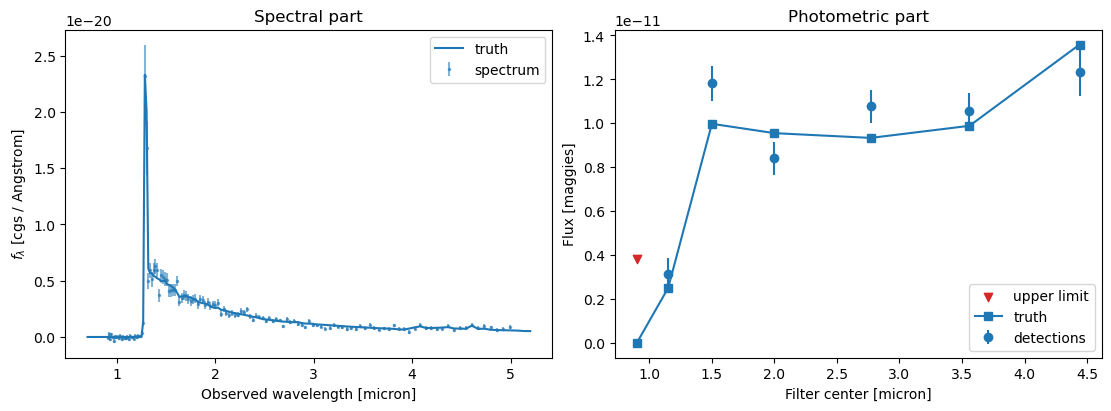

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].errorbar(wave_obs_a[spec_mask] / 1e4, obs_spec[spec_mask], yerr=spec_sigma[spec_mask], fmt='.', ms=3, alpha=0.55, label='spectrum')
axes[0].plot(wave_obs_a / 1e4, true_spec, color='tab:blue', lw=1.5, label='truth')
axes[0].set_xlabel('Observed wavelength [micron]')
axes[0].set_ylabel(r'$f_\lambda$ [cgs / Angstrom]')
axes[0].legend()
axes[0].set_title('Spectral part')

centers = np.asarray([center for _, center, _ in filter_specs]) / 1e4
axes[1].errorbar(centers[~upper_limit_mask], obs_phot[~upper_limit_mask], yerr=phot_sigma[~upper_limit_mask], fmt='o', label='detections')
axes[1].scatter(centers[upper_limit_mask], upper_limit[upper_limit_mask], marker='v', color='tab:red', label='upper limit')
axes[1].plot(centers, true_phot, 's-', color='tab:blue', label='truth')
axes[1].set_xlabel('Filter center [micron]')
axes[1].set_ylabel('Flux [maggies]')
axes[1].legend()
axes[1].set_title('Photometric part')
fig.savefig(OUTPUT_DIR / 'joint_mock_data.png', dpi=180)
plt.show()


In [7]:

initial_theta = parameter_space.from_dict({
    'log10_mass': 8.7,
    'z': 9.3,
    'logzsol': -1.0,
    'E_BV_young': 0.10,
    'tau_gyr': 0.30,
    'tage_fraction': 0.42,
    'gas_logu': -2.45,
    'gas_logoh': -1.05,
})

if RUN_NUTS:
    result, nuts_elapsed = run_short_nuts(model, joint_data, initial_theta)
    samples = np.asarray(result.samples)
    rows = posterior_summary(samples, result.theta_names, truth)

    map_info = result.extra_fields.get('map_initialization')
    summary_extra = {'nuts_elapsed_seconds': nuts_elapsed, 'num_warmup': NUM_WARMUP, 'num_samples': NUM_SAMPLES}
    if map_info is not None:
        map_theta = np.asarray(map_info['initial_theta'], dtype=float)
        print('\nQMC+Nadam initializer:')
        print('  transformed log density:', float(map_info['initial_log_density']))
        for name, value, true_value in zip(result.theta_names, map_theta, truth):
            print(f'  {name:12s} init={value: .4f} truth={true_value: .4f}')
        np.savez(
            OUTPUT_DIR / 'qmc_nadam_initialization.npz',
            initial_theta=map_theta,
            initial_raw=np.asarray(map_info['initial_raw'], dtype=float),
            candidate_theta=np.asarray(map_info['candidate_theta'], dtype=float),
            candidate_log_density=np.asarray(map_info['candidate_log_density'], dtype=float),
            optimized_theta=np.asarray(map_info['optimized_theta'], dtype=float),
            optimized_log_density=np.asarray(map_info['optimized_log_density'], dtype=float),
            theta_names=np.asarray(result.theta_names),
        )
        summary_extra['map_initialization'] = {
            'initial_log_density': float(map_info['initial_log_density']),
            'initial_theta': {name: float(value) for name, value in zip(result.theta_names, map_theta)},
            'candidate_log_density': np.asarray(map_info['candidate_log_density'], dtype=float).tolist(),
            'optimized_log_density': np.asarray(map_info['optimized_log_density'], dtype=float).tolist(),
            'settings': map_info['settings'],
        }

    print('\nPosterior summary:')
    for row in rows:
        print(f"{row['name']:12s} truth={row['truth']: .4f} median={row['median']: .4f} [{row['q16']: .4f}, {row['q84']: .4f}]")
    save_summary(OUTPUT_DIR / 'nuts_summary.json', rows, summary_extra)
    np.savez(OUTPUT_DIR / 'nuts_samples.npz', samples=samples, theta_names=np.asarray(result.theta_names), truth=truth)
else:
    samples = np.empty((0, parameter_space.ndim))
    print('Skipped NUTS because RUN_NUTS is False.')


  0%|          | 0/550 [00:00<?, ?it/s]

warmup:   0%|          | 0/550 [00:10<?, ?it/s, 511 steps of size 9.28e-04. acc. prob=0.20]

warmup:   1%|          | 6/550 [00:11<16:46,  1.85s/it, 511 steps of size 1.03e-03. acc. prob=0.32]

warmup:   1%|▏         | 7/550 [00:15<20:52,  2.31s/it, 511 steps of size 8.13e-04. acc. prob=0.39]

warmup:   1%|▏         | 8/550 [00:19<23:49,  2.64s/it, 463 steps of size 1.06e-03. acc. prob=0.46]

...

sample: 100%|█████████▉| 548/550 [37:12<00:08,  4.34s/it, 511 steps of size 5.82e-03. acc. prob=0.95]

sample: 100%|█████████▉| 549/550 [37:16<00:04,  4.34s/it, 511 steps of size 5.82e-03. acc. prob=0.95]

sample: 100%|██████████| 550/550 [37:21<00:00,  4.33s/it, 511 steps of size 5.82e-03. acc. prob=0.95]

sample: 100%|██████████| 550/550 [37:21<00:00,  4.07s/it, 511 steps of size 5.82e-03. acc. prob=0.95]

NUTS elapsed: 2298.2 s; samples/sec: 0.218

QMC+Nadam initializer:
  transformed log density: 6336.303534321396
  log10_mass   init= 9.0373 truth= 8.9000
  z            init= 9.6004 truth= 9.6000
  logzsol      init=-0.3453 truth=-0.7500
  E_BV_young   init= 0.0670 truth= 0.0700
  tau_gyr      init= 1.0178 truth= 0.2200
  tage_fraction init= 0.7534 truth= 0.5000
  gas_logu     init=-2.5644 truth=-2.1000
  gas_logoh    init=-0.4945 truth=-0.8000

Posterior summary:
log10_mass   truth= 8.9000 median= 9.0539 [ 9.0099,  9.1004]
z            truth= 9.6000 median= 9.6011 [ 9.5988,  9.6043]
logzsol      truth=-0.7500 median=-0.5155 [-0.7163, -0.3065]
E_BV_young   truth= 0.0700 median= 0.0543 [ 0.0433,  0.0653]
tau_gyr      truth= 0.2200 median= 0.8203 [ 0.4052,  1.4335]
tage_fraction truth= 0.5000 median= 0.8799 [ 0.7582,  0.9352]
gas_logu     truth=-2.1000 median=-1.7486 [-2.6071, -1.1974]
gas_logoh    truth=-0.8000 median=-1.1241 [-1.7790, -0.1899]
Saved summary: /Users/gregoire/Documents/S

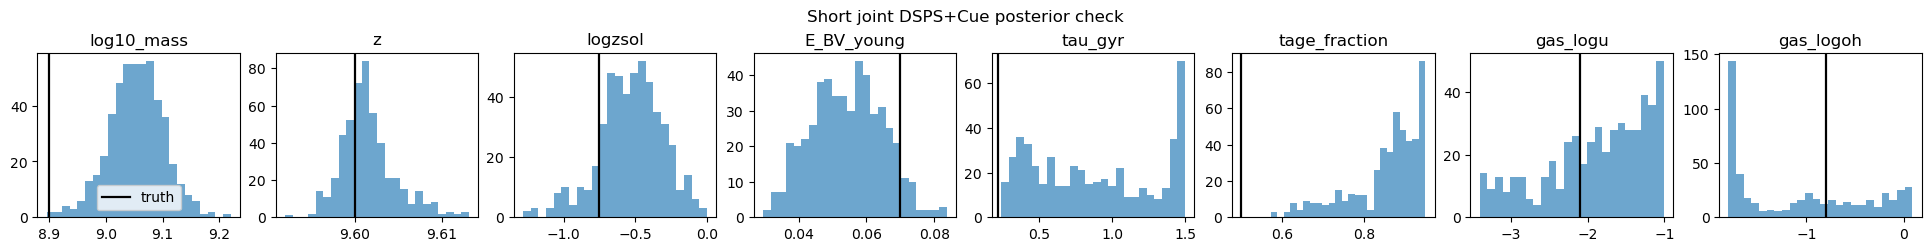

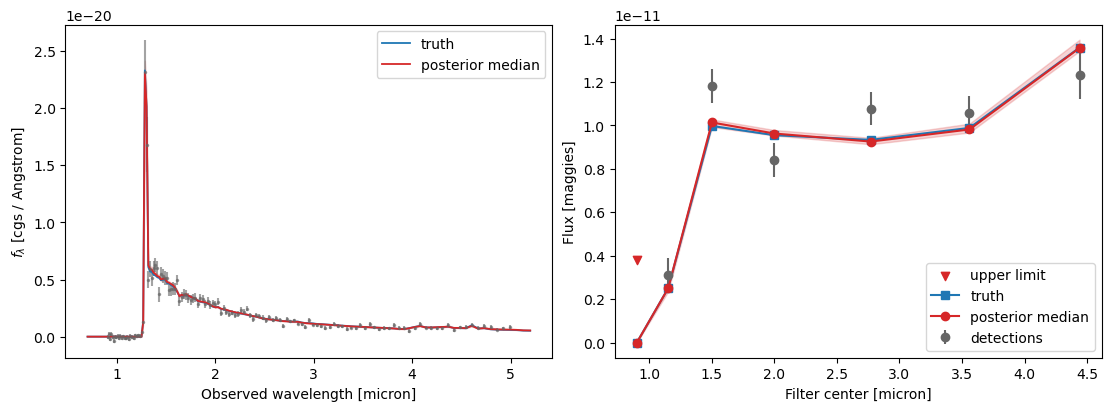

In [8]:

if RUN_NUTS:
    fig = plot_corner_like(samples, result.theta_names, truth, 'Short joint DSPS+Cue posterior check')
    fig.savefig(OUTPUT_DIR / 'posterior_marginals.png', dpi=180)
    plt.show()

    take = np.linspace(0, len(samples) - 1, min(20, len(samples))).astype(int)
    pred_spec, pred_phot = [], []
    for theta in samples[take]:
        state = model.run_modules_mass_scaled(jnp.asarray(theta))
        pred_spec.append(np.asarray(model_spectrum_on_observed_pixels(
            state.wave_obs_a, state.flux_lambda_cgs, jnp.asarray(wave_obs_a), pixel_edges,
            resample_mode='bin', resolving_power=resolving_power,
        )))
        pred_phot.append(np.asarray(model.predict_photometry(jnp.asarray(theta))))
    pred_spec = np.asarray(pred_spec)
    pred_phot = np.asarray(pred_phot)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    spec_med = np.median(pred_spec, axis=0)
    spec_lo, spec_hi = np.quantile(pred_spec, [0.16, 0.84], axis=0)
    axes[0].errorbar(wave_obs_a[spec_mask] / 1e4, obs_spec[spec_mask], yerr=spec_sigma[spec_mask], fmt='.', ms=3, color='0.4', alpha=0.6)
    axes[0].plot(wave_obs_a / 1e4, true_spec, color='tab:blue', lw=1.3, label='truth')
    axes[0].plot(wave_obs_a / 1e4, spec_med, color='tab:red', lw=1.3, label='posterior median')
    axes[0].fill_between(wave_obs_a / 1e4, spec_lo, spec_hi, color='tab:red', alpha=0.2)
    axes[0].set_xlabel('Observed wavelength [micron]')
    axes[0].set_ylabel(r'$f_\lambda$ [cgs / Angstrom]')
    axes[0].legend()

    phot_med = np.median(pred_phot, axis=0)
    phot_lo, phot_hi = np.quantile(pred_phot, [0.16, 0.84], axis=0)
    axes[1].errorbar(centers[~upper_limit_mask], obs_phot[~upper_limit_mask], yerr=phot_sigma[~upper_limit_mask], fmt='o', color='0.4', label='detections')
    axes[1].scatter(centers[upper_limit_mask], upper_limit[upper_limit_mask], marker='v', color='tab:red', label='upper limit')
    axes[1].plot(centers, true_phot, 's-', color='tab:blue', label='truth')
    axes[1].plot(centers, phot_med, 'o-', color='tab:red', label='posterior median')
    axes[1].fill_between(centers, phot_lo, phot_hi, color='tab:red', alpha=0.2)
    axes[1].set_xlabel('Filter center [micron]')
    axes[1].set_ylabel('Flux [maggies]')
    axes[1].legend()
    fig.savefig(OUTPUT_DIR / 'posterior_predictive_joint.png', dpi=180)
    plt.show()
